In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
pip install -U inference-sdk

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.3/74.3 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.5/62.5 MB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 87.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 5.9 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
  Attempting uninstall: pillow
    Found existing installation: pillow 11.3.0
    Uninstalling pillow-11.3.0:
      Successfully uninstalled pillow-11.3.0
  Attempting uninstall: opencv-python
    Found exist

In [ ]:
!pip install scipy


Detected lids: 6
Lid 0: 258.47 deg
Lid 1: 124.70 deg
Lid 2: 269.65 deg
Lid 3: 304.26 deg
Lid 4: 53.55 deg
Lid 5: 135.81 deg


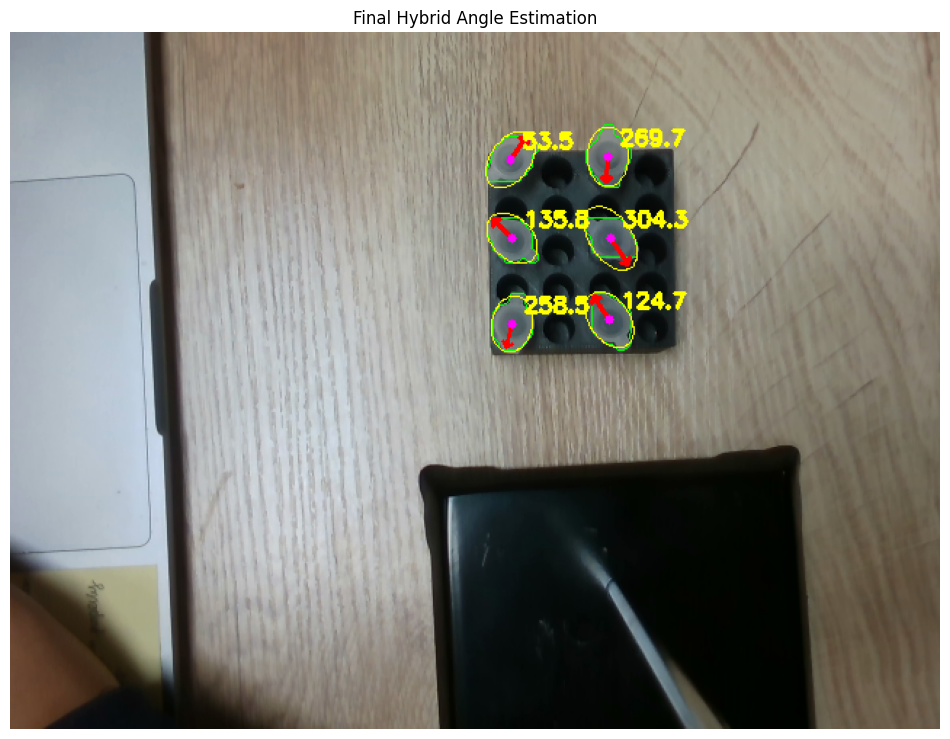


Saved result to:
/content/final_result.jpg


In [ ]:
#@title Ellipse based method
import cv2
import numpy as np
import math
import matplotlib.pyplot as plt
from inference_sdk import InferenceHTTPClient

# ============================================================
# CONFIG
# ============================================================

API_KEY = "vof93SgrEEFl6QUIp6BI"

# MODEL 1 -> SEGMENTATION
SEGMENTATION_MODEL_ID = "zeon-9tvbv/1"

# MODEL 2 -> KEYPOINTS
KEYPOINT_MODEL_ID = "zeon-2/2"

IMAGE_PATH = "/content/drive/MyDrive/images/2659ffa5-color.png"

PADDING = 15

# ============================================================
# INITIALIZE CLIENT
# ============================================================

CLIENT = InferenceHTTPClient(
    api_url="https://detect.roboflow.com",
    api_key=API_KEY
)

# ============================================================
# LOAD IMAGE
# ============================================================

image = cv2.imread(IMAGE_PATH)

orig = image.copy()

# ============================================================
# RUN SEGMENTATION MODEL
# ============================================================

result = CLIENT.infer(
    IMAGE_PATH,
    model_id=SEGMENTATION_MODEL_ID
)

predictions = result["predictions"]

print(f"\nDetected lids: {len(predictions)}")

# ============================================================
# PROCESS EACH LID
# ============================================================

for idx, pred in enumerate(predictions):

    try:

        # ----------------------------------------------------
        # GET CONTOUR
        # ----------------------------------------------------

        points = pred["points"]

        contour = np.array(
            [[int(p["x"]), int(p["y"])] for p in points],
            dtype=np.int32
        )

        if len(contour) < 5:
            continue

        # ----------------------------------------------------
        # FIT ELLIPSE
        # ----------------------------------------------------

        ellipse = cv2.fitEllipse(contour)

        (cx, cy), (axis1, axis2), raw_angle = ellipse

        cx = int(cx)
        cy = int(cy)

        # ----------------------------------------------------
        # DETERMINE MAJOR AXIS
        # ----------------------------------------------------

        if axis1 >= axis2:
            major_axis = axis1
            minor_axis = axis2
            major_angle = raw_angle

        else:
            major_axis = axis2
            minor_axis = axis1
            major_angle = raw_angle + 90

        major_angle = major_angle % 360

        # ----------------------------------------------------
        # DRAW CONTOUR
        # ----------------------------------------------------

        cv2.drawContours(
            orig,
            [contour],
            -1,
            (0,255,0),
            1
        )

        # ----------------------------------------------------
        # DRAW CORRECTED ELLIPSE
        # ----------------------------------------------------

        corrected_ellipse = (
            (cx, cy),
            (major_axis, minor_axis),
            major_angle
        )

        cv2.ellipse(
            orig,
            corrected_ellipse,
            (0,255,255),
            1
        )

        # ----------------------------------------------------
        # CREATE TIGHT CROP
        # ----------------------------------------------------

        x, y, w, h = cv2.boundingRect(contour)

        x1 = max(0, x - PADDING)
        y1 = max(0, y - PADDING)

        x2 = min(image.shape[1], x + w + PADDING)
        y2 = min(image.shape[0], y + h + PADDING)

        crop = image[y1:y2, x1:x2]

        crop_path = f"/content/temp_crop_{idx}.jpg"

        cv2.imwrite(crop_path, crop)

        # ----------------------------------------------------
        # RUN KEYPOINT MODEL
        # ----------------------------------------------------

        kp_result = CLIENT.infer(
            crop_path,
            model_id=KEYPOINT_MODEL_ID
        )

        kp_predictions = kp_result["predictions"]

        if len(kp_predictions) == 0:
            print(f"No keypoints for lid {idx}")
            continue

        kp = kp_predictions[0]

        keypoints = kp["keypoints"]

        hinge = None
        tab = None

        # ----------------------------------------------------
        # EXTRACT TAB + HINGE
        # ----------------------------------------------------

        for k in keypoints:

            cls = k["class"].lower()

            px = k["x"] + x1
            py = k["y"] + y1

            if "hinge" in cls:
                hinge = np.array([px, py])

            elif "tab" in cls:
                tab = np.array([px, py])

        if hinge is None or tab is None:
            print(f"Missing hinge/tab on lid {idx}")
            continue

        # ====================================================
        # MAJOR AXIS VECTOR
        # ====================================================

        theta = np.deg2rad(major_angle)

        axis_vec = np.array([
            np.cos(theta),
            -np.sin(theta)
        ])

        # TWO POSSIBLE DIRECTIONS
        axis_vec_1 = axis_vec
        axis_vec_2 = -axis_vec

        # ====================================================
        # KEYPOINT DIRECTION VECTOR
        # ====================================================

        kp_vec = tab - hinge

        kp_norm = np.linalg.norm(kp_vec)

        if kp_norm < 1e-6:
            continue

        kp_vec = kp_vec / kp_norm

        # IMAGE COORDINATE FIX
        kp_vec[1] *= -1

        # ====================================================
        # CHOOSE BEST ORIENTATION
        # ====================================================

        dot1 = np.dot(axis_vec_1, kp_vec)
        dot2 = np.dot(axis_vec_2, kp_vec)

        if dot1 >= dot2:
            final_vec = axis_vec_1
        else:
            final_vec = axis_vec_2

        # ====================================================
        # FINAL ANGLE
        # ====================================================
        true_angle = np.degrees(
            np.arctan2(-final_vec[1], final_vec[0])
        )

        true_angle = true_angle % 360

        # ====================================================
        # CONVERT TO ASSIGNMENT CONVENTION
        # Anti-clockwise from +x axis
        # ====================================================

        true_angle = (360 - true_angle) % 360
        # true_angle = np.degrees(
        #     np.arctan2(-final_vec[1], final_vec[0])
        # )

        # true_angle = true_angle % 360

        # ----------------------------------------------------
        # DRAW FINAL ARROW
        # ----------------------------------------------------

        arrow_length = int(major_axis * 0.45)

        end_x = int(cx + arrow_length * final_vec[0])
        end_y = int(cy - arrow_length * final_vec[1])

        cv2.arrowedLine(
            orig,
            (cx, cy),
            (end_x, end_y),
            (0,0,255),
            2,
            tipLength=0.25
        )

        # ----------------------------------------------------
        # DRAW CENTER
        # ----------------------------------------------------

        cv2.circle(
            orig,
            (cx, cy),
            3,
            (255,0,255),
            -1
        )

        # ----------------------------------------------------
        # DRAW TEXT
        # ----------------------------------------------------

        cv2.putText(
            orig,
            f"{true_angle:.1f}",
            (cx + 8, cy - 8),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (0,255,255),
            2
        )

        print(f"Lid {idx}: {true_angle:.2f} deg")

    except Exception as e:

        print(f"\nFailed on lid {idx}")
        print(e)

# ============================================================
# DISPLAY FINAL RESULT
# ============================================================

rgb = cv2.cvtColor(orig, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12,12))

plt.imshow(rgb)

plt.title("Final Hybrid Angle Estimation")

plt.axis("off")

plt.show()

# ============================================================
# SAVE OUTPUT
# ============================================================

output_path = "/content/final_result.jpg"

cv2.imwrite(output_path, orig)

print(f"\nSaved result to:\n{output_path}")

In [ ]:
#@title Ellipse CSV generation
import os
import cv2
import math
import numpy as np
import pandas as pd
from tqdm import tqdm
from inference_sdk import InferenceHTTPClient

# ============================================================
# CONFIG
# ============================================================

API_KEY = "vof93SgrEEFl6QUIp6BI"

# MODEL 1 -> SEGMENTATION
SEGMENTATION_MODEL_ID = "zeon-9tvbv/1"

# MODEL 2 -> NEW KEYPOINT MODEL
KEYPOINT_MODEL_ID = "zeon-2/2"

IMAGE_FOLDER = "/content/drive/MyDrive/images"

OUTPUT_CSV = "/content/predicted_angles_2.csv"

PADDING = 15

# ============================================================
# INITIALIZE CLIENT
# ============================================================

CLIENT = InferenceHTTPClient(
    api_url="https://detect.roboflow.com",
    api_key=API_KEY
)

# ============================================================
# STORAGE
# ============================================================

rows = []

# ============================================================
# PROCESS IMAGES
# ============================================================

image_files = sorted([
    f for f in os.listdir(IMAGE_FOLDER)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
])

print(f"\nFound {len(image_files)} images")

# ============================================================
# LOOP
# ============================================================

for image_name in tqdm(image_files):

    image_path = os.path.join(
        IMAGE_FOLDER,
        image_name
    )

    image = cv2.imread(image_path)

    if image is None:
        continue

    try:

        # ----------------------------------------------------
        # RUN SEGMENTATION
        # ----------------------------------------------------

        result = CLIENT.infer(
            image_path,
            model_id=SEGMENTATION_MODEL_ID
        )

        predictions = result["predictions"]

        image_rows = []

        # ----------------------------------------------------
        # PROCESS EACH LID
        # ----------------------------------------------------

        for idx, pred in enumerate(predictions):

            try:

                # ------------------------------------------------
                # CONTOUR
                # ------------------------------------------------

                points = pred["points"]

                contour = np.array(
                    [[int(p["x"]), int(p["y"])] for p in points],
                    dtype=np.int32
                )

                if len(contour) < 5:
                    continue

                # ------------------------------------------------
                # ELLIPSE
                # ------------------------------------------------

                ellipse = cv2.fitEllipse(contour)

                (cx, cy), (axis1, axis2), raw_angle = ellipse

                # major axis correction
                if axis1 >= axis2:

                    major_axis = axis1
                    minor_axis = axis2
                    major_angle = raw_angle

                else:

                    major_axis = axis2
                    minor_axis = axis1
                    major_angle = raw_angle + 90

                major_angle %= 360

                # ------------------------------------------------
                # BOUNDING RECT
                # ------------------------------------------------

                x, y, w, h = cv2.boundingRect(contour)

                x1 = max(0, x - PADDING)
                y1 = max(0, y - PADDING)

                x2 = min(
                    image.shape[1],
                    x + w + PADDING
                )

                y2 = min(
                    image.shape[0],
                    y + h + PADDING
                )

                crop = image[y1:y2, x1:x2]

                crop_path = "/content/temp_crop.jpg"

                cv2.imwrite(crop_path, crop)

                # ------------------------------------------------
                # KEYPOINT MODEL
                # ------------------------------------------------

                kp_result = CLIENT.infer(
                    crop_path,
                    model_id=KEYPOINT_MODEL_ID
                )

                kp_predictions = kp_result["predictions"]

                if len(kp_predictions) == 0:
                    continue

                kp = kp_predictions[0]

                keypoints = kp["keypoints"]

                hinge = None
                tab = None

                for k in keypoints:

                    cls = k["class"].lower()

                    px = k["x"] + x1
                    py = k["y"] + y1

                    if "hinge" in cls:
                        hinge = np.array([px, py])

                    elif "tab" in cls:
                        tab = np.array([px, py])

                if hinge is None or tab is None:
                    continue

                # =================================================
                # AXIS VECTOR
                # =================================================

                theta = np.deg2rad(major_angle)

                axis_vec = np.array([
                    np.cos(theta),
                    -np.sin(theta)
                ])

                axis_vec_1 = axis_vec
                axis_vec_2 = -axis_vec

                # =================================================
                # KEYPOINT VECTOR
                # =================================================

                kp_vec = tab - hinge

                kp_norm = np.linalg.norm(kp_vec)

                if kp_norm < 1e-6:
                    continue

                kp_vec = kp_vec / kp_norm

                kp_vec[1] *= -1

                # =================================================
                # SELECT DIRECTION
                # =================================================

                dot1 = np.dot(axis_vec_1, kp_vec)
                dot2 = np.dot(axis_vec_2, kp_vec)

                if dot1 >= dot2:
                    final_vec = axis_vec_1
                else:
                    final_vec = axis_vec_2

                # =================================================
                # FINAL ANGLE
                # =================================================

                true_angle = np.degrees(
                    np.arctan2(
                        -final_vec[1],
                        final_vec[0]
                    )
                )

                true_angle %= 360

                # assignment convention
                true_angle = (
                    360 - true_angle
                ) % 360

                # =================================================
                # SAVE ROW
                # =================================================

                image_rows.append({

                    "image": image_name,

                    "center_x": round(cx, 1),
                    "center_y": round(cy, 1),

                    "bbox_x": round(x, 1),
                    "bbox_y": round(y, 1),

                    "bbox_w": round(w, 1),
                    "bbox_h": round(h, 1),

                    "bbox_rotation": 0,

                    "angle_deg": round(true_angle, 1)
                })

            except Exception:
                continue

        # =====================================================
        # SORT CLOCKWISE / POSITIONALLY
        # =====================================================

        image_rows = sorted(
            image_rows,
            key=lambda r: (r["center_x"], r["center_y"])
        )

        rows.extend(image_rows)

    except Exception as e:

        print(f"\nFailed image: {image_name}")
        print(e)

# ============================================================
# SAVE CSV
# ============================================================

df = pd.DataFrame(rows)

df.to_csv(
    OUTPUT_CSV,
    index=False
)

print("\n===================================")
print("DONE")
print("===================================")

print(f"\nSaved CSV:\n{OUTPUT_CSV}")

print(f"\nRows: {len(df)}")


Found 70 images


100%|██████████| 70/70 [05:31<00:00,  4.74s/it]


DONE

Saved CSV:
/content/predicted_angles_2.csv

Rows: 371



Detected lids: 6
Lid 0: 258.31 deg
Lid 1: 112.37 deg
Lid 2: 265.53 deg
Lid 3: 328.86 deg
Lid 4: 33.25 deg
Lid 5: 140.65 deg


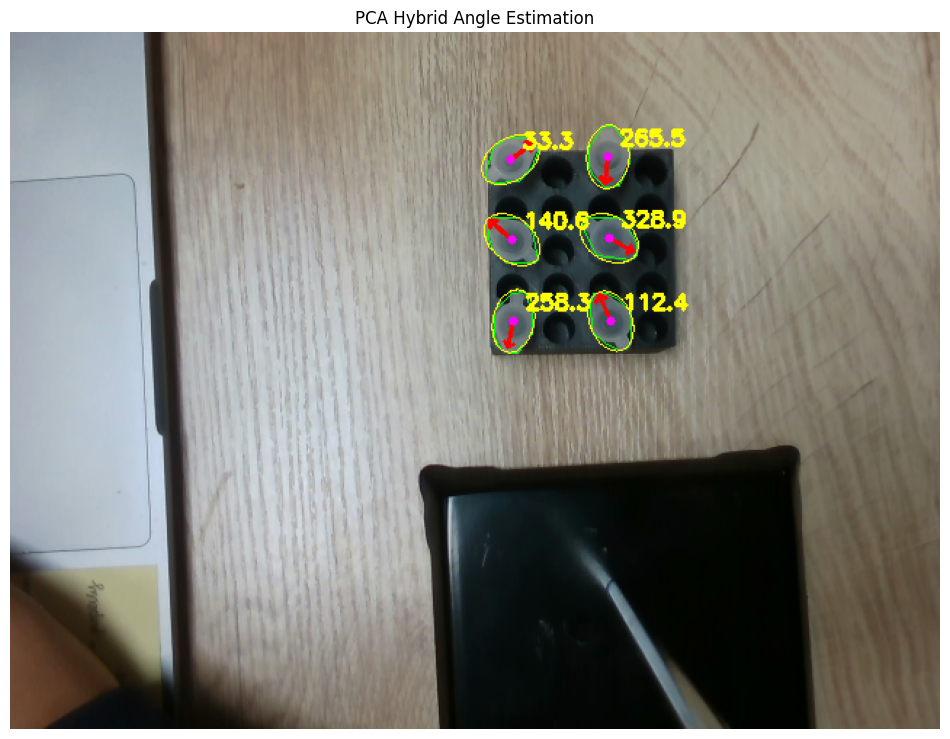


Saved result to:
/content/pca_result.jpg


In [ ]:
#@title PCA based method
# ============================================================
# PCA-BASED HYBRID ANGLE ESTIMATION
# ============================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
from inference_sdk import InferenceHTTPClient

# ============================================================
# CONFIG
# ============================================================

API_KEY = "vof93SgrEEFl6QUIp6BI"

# MODEL 1 -> SEGMENTATION
SEGMENTATION_MODEL_ID = "zeon-9tvbv/1"

# MODEL 2 -> KEYPOINTS
KEYPOINT_MODEL_ID = "zeon-2/2"

IMAGE_PATH = "/content/drive/MyDrive/images/2659ffa5-color.png"

PADDING = 15

# ============================================================
# INITIALIZE CLIENT
# ============================================================

CLIENT = InferenceHTTPClient(
    api_url="https://detect.roboflow.com",
    api_key=API_KEY
)

# ============================================================
# LOAD IMAGE
# ============================================================

image = cv2.imread(IMAGE_PATH)

orig = image.copy()

# ============================================================
# RUN SEGMENTATION MODEL
# ============================================================

result = CLIENT.infer(
    IMAGE_PATH,
    model_id=SEGMENTATION_MODEL_ID
)

predictions = result["predictions"]

print(f"\nDetected lids: {len(predictions)}")

# ============================================================
# PROCESS EACH LID
# ============================================================

for idx, pred in enumerate(predictions):

    try:

        # ----------------------------------------------------
        # GET CONTOUR
        # ----------------------------------------------------

        points = pred["points"]

        contour = np.array(
            [[int(p["x"]), int(p["y"])] for p in points],
            dtype=np.int32
        )

        if len(contour) < 5:
            continue

        # ====================================================
        # SMOOTH CONTOUR
        # ====================================================

        contour = cv2.convexHull(contour)

        epsilon = 0.01 * cv2.arcLength(contour, True)

        contour = cv2.approxPolyDP(
            contour,
            epsilon,
            True
        )

        # ====================================================
        # FIT ELLIPSE (VISUALIZATION ONLY)
        # ====================================================

        ellipse = cv2.fitEllipse(contour)

        (cx, cy), (axis1, axis2), raw_angle = ellipse

        cx = int(cx)
        cy = int(cy)

        # ----------------------------------------------------
        # MAJOR / MINOR AXES
        # ----------------------------------------------------

        if axis1 >= axis2:

            major_axis = axis1
            minor_axis = axis2

        else:

            major_axis = axis2
            minor_axis = axis1

        # ====================================================
        # PCA ORIENTATION
        # ====================================================

        pts = contour.reshape(-1, 2).astype(np.float32)

        mean, eigenvectors = cv2.PCACompute(
            pts,
            mean=None
        )

        principal_vec = eigenvectors[0]

        vx = principal_vec[0]
        vy = principal_vec[1]

        # image coordinate correction
        vy = -vy

        # PCA angle
        major_angle = np.degrees(
            np.arctan2(vy, vx)
        )

        major_angle = major_angle % 360

        # ====================================================
        # DRAW CONTOUR
        # ====================================================

        cv2.drawContours(
            orig,
            [contour],
            -1,
            (0,255,0),
            1
        )

        # ====================================================
        # DRAW PCA ELLIPSE
        # ====================================================

        corrected_ellipse = (
            (cx, cy),
            (major_axis, minor_axis),
            (-major_angle) % 360
        )

        cv2.ellipse(
            orig,
            corrected_ellipse,
            (0,255,255),
            1
        )

        # ====================================================
        # CREATE TIGHT CROP
        # ====================================================

        x, y, w, h = cv2.boundingRect(contour)

        x1 = max(0, x - PADDING)
        y1 = max(0, y - PADDING)

        x2 = min(
            image.shape[1],
            x + w + PADDING
        )

        y2 = min(
            image.shape[0],
            y + h + PADDING
        )

        crop = image[y1:y2, x1:x2]

        crop_path = f"/content/temp_crop_{idx}.jpg"

        cv2.imwrite(crop_path, crop)

        # ====================================================
        # RUN KEYPOINT MODEL
        # ====================================================

        kp_result = CLIENT.infer(
            crop_path,
            model_id=KEYPOINT_MODEL_ID
        )

        kp_predictions = kp_result["predictions"]

        if len(kp_predictions) == 0:
            print(f"No keypoints for lid {idx}")
            continue

        kp = kp_predictions[0]

        keypoints = kp["keypoints"]

        hinge = None
        tab = None

        # ====================================================
        # EXTRACT TAB + HINGE
        # ====================================================

        for k in keypoints:

            cls = k["class"].lower()

            px = k["x"] + x1
            py = k["y"] + y1

            if "hinge" in cls:
                hinge = np.array([px, py])

            elif "tab" in cls:
                tab = np.array([px, py])

        if hinge is None or tab is None:
            print(f"Missing hinge/tab on lid {idx}")
            continue

        # ====================================================
        # PCA AXIS VECTOR
        # ====================================================

        theta = np.deg2rad(major_angle)

        axis_vec = np.array([
            np.cos(theta),
            np.sin(theta)
        ])

        # two possible directions
        axis_vec_1 = axis_vec
        axis_vec_2 = -axis_vec

        # ====================================================
        # KEYPOINT VECTOR
        # ====================================================

        kp_vec = tab - hinge

        kp_norm = np.linalg.norm(kp_vec)

        if kp_norm < 1e-6:
            continue

        kp_vec = kp_vec / kp_norm

        # image coordinate fix
        kp_vec[1] *= -1

        # ====================================================
        # CHOOSE BEST DIRECTION
        # ====================================================

        dot1 = np.dot(axis_vec_1, kp_vec)
        dot2 = np.dot(axis_vec_2, kp_vec)

        if dot1 >= dot2:
            final_vec = axis_vec_1
        else:
            final_vec = axis_vec_2

        # ====================================================
        # FINAL ANGLE
        # ====================================================

        true_angle = np.degrees(
            np.arctan2(
                final_vec[1],
                final_vec[0]
            )
        )

        true_angle = true_angle % 360

        # # assignment convention
        # true_angle = (360 - true_angle) % 360

        # ====================================================
        # DRAW FINAL ARROW
        # ====================================================

        arrow_length = int(major_axis * 0.45)

        end_x = int(
            cx + arrow_length * final_vec[0]
        )

        end_y = int(
            cy - arrow_length * final_vec[1]
        )

        cv2.arrowedLine(
            orig,
            (cx, cy),
            (end_x, end_y),
            (0,0,255),
            2,
            tipLength=0.25
        )

        # ====================================================
        # DRAW CENTER
        # ====================================================

        cv2.circle(
            orig,
            (cx, cy),
            3,
            (255,0,255),
            -1
        )

        # ====================================================
        # DRAW TEXT
        # ====================================================

        cv2.putText(
            orig,
            f"{true_angle:.1f}",
            (cx + 8, cy - 8),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (0,255,255),
            2
        )

        print(f"Lid {idx}: {true_angle:.2f} deg")

    except Exception as e:

        print(f"\nFailed on lid {idx}")
        print(e)

# ============================================================
# DISPLAY FINAL RESULT
# ============================================================

rgb = cv2.cvtColor(
    orig,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(12,12))

plt.imshow(rgb)

plt.title("PCA Hybrid Angle Estimation")

plt.axis("off")

plt.show()

# ============================================================
# SAVE OUTPUT
# ============================================================

output_path = "/content/pca_result.jpg"

cv2.imwrite(output_path, orig)

print(f"\nSaved result to:\n{output_path}")

In [ ]:
#@title PCA CSV generation
# ============================================================
# FULL FOLDER PCA-BASED ANGLE ESTIMATION
# OUTPUT -> predicted_angles_pca.csv
# ============================================================

import os
import cv2
import math
import numpy as np
import pandas as pd
from tqdm import tqdm
from inference_sdk import InferenceHTTPClient

# ============================================================
# CONFIG
# ============================================================

API_KEY = "vof93SgrEEFl6QUIp6BI"

# MODEL 1 -> SEGMENTATION
SEGMENTATION_MODEL_ID = "zeon-9tvbv/1"

# MODEL 2 -> KEYPOINT MODEL
KEYPOINT_MODEL_ID = "zeon-2/2"

IMAGE_FOLDER = "/content/drive/MyDrive/images"

OUTPUT_CSV = "/content/predicted_angles_pca.csv"

PADDING = 15

# ============================================================
# INITIALIZE CLIENT
# ============================================================

CLIENT = InferenceHTTPClient(
    api_url="https://detect.roboflow.com",
    api_key=API_KEY
)

# ============================================================
# STORAGE
# ============================================================

rows = []

# ============================================================
# GET IMAGES
# ============================================================

image_files = sorted([
    f for f in os.listdir(IMAGE_FOLDER)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
])

print(f"\nFound {len(image_files)} images")

# ============================================================
# PROCESS EACH IMAGE
# ============================================================

for image_name in tqdm(image_files):

    image_path = os.path.join(
        IMAGE_FOLDER,
        image_name
    )

    image = cv2.imread(image_path)

    if image is None:
        continue

    try:

        # ====================================================
        # SEGMENTATION INFERENCE
        # ====================================================

        result = CLIENT.infer(
            image_path,
            model_id=SEGMENTATION_MODEL_ID
        )

        predictions = result["predictions"]

        image_rows = []

        # ====================================================
        # PROCESS EACH LID
        # ====================================================

        for idx, pred in enumerate(predictions):

            try:

                # ------------------------------------------------
                # CONTOUR
                # ------------------------------------------------

                points = pred["points"]

                contour = np.array(
                    [[int(p["x"]), int(p["y"])] for p in points],
                    dtype=np.int32
                )

                if len(contour) < 5:
                    continue

                # =================================================
                # SMOOTH CONTOUR
                # =================================================

                contour = cv2.convexHull(contour)

                epsilon = 0.01 * cv2.arcLength(
                    contour,
                    True
                )

                contour = cv2.approxPolyDP(
                    contour,
                    epsilon,
                    True
                )

                if len(contour) < 5:
                    continue

                # =================================================
                # ELLIPSE (FOR CENTER + SIZE)
                # =================================================

                ellipse = cv2.fitEllipse(contour)

                (cx, cy), (axis1, axis2), _ = ellipse

                # ------------------------------------------------
                # MAJOR / MINOR AXIS
                # ------------------------------------------------

                if axis1 >= axis2:

                    major_axis = axis1
                    minor_axis = axis2

                else:

                    major_axis = axis2
                    minor_axis = axis1

                # =================================================
                # PCA ORIENTATION
                # =================================================

                pts = contour.reshape(-1, 2).astype(np.float32)

                mean, eigenvectors = cv2.PCACompute(
                    pts,
                    mean=None
                )

                principal_vec = eigenvectors[0]

                vx = principal_vec[0]
                vy = principal_vec[1]

                # image coordinate correction
                vy = -vy

                major_angle = np.degrees(
                    np.arctan2(vy, vx)
                )

                major_angle = major_angle % 360

                # =================================================
                # BOUNDING RECT
                # =================================================

                x, y, w, h = cv2.boundingRect(contour)

                x1 = max(0, x - PADDING)
                y1 = max(0, y - PADDING)

                x2 = min(
                    image.shape[1],
                    x + w + PADDING
                )

                y2 = min(
                    image.shape[0],
                    y + h + PADDING
                )

                crop = image[y1:y2, x1:x2]

                crop_path = "/content/temp_crop.jpg"

                cv2.imwrite(crop_path, crop)

                # =================================================
                # KEYPOINT INFERENCE
                # =================================================

                kp_result = CLIENT.infer(
                    crop_path,
                    model_id=KEYPOINT_MODEL_ID
                )

                kp_predictions = kp_result["predictions"]

                if len(kp_predictions) == 0:
                    continue

                kp = kp_predictions[0]

                keypoints = kp["keypoints"]

                hinge = None
                tab = None

                # =================================================
                # EXTRACT KEYPOINTS
                # =================================================

                for k in keypoints:

                    cls = k["class"].lower()

                    px = k["x"] + x1
                    py = k["y"] + y1

                    if "hinge" in cls:
                        hinge = np.array([px, py])

                    elif "tab" in cls:
                        tab = np.array([px, py])

                if hinge is None or tab is None:
                    continue

                # =================================================
                # PCA AXIS VECTOR
                # =================================================

                theta = np.deg2rad(major_angle)

                axis_vec = np.array([
                    np.cos(theta),
                    np.sin(theta)
                ])

                axis_vec_1 = axis_vec
                axis_vec_2 = -axis_vec

                # =================================================
                # KEYPOINT VECTOR
                # =================================================

                kp_vec = tab - hinge

                kp_norm = np.linalg.norm(kp_vec)

                if kp_norm < 1e-6:
                    continue

                kp_vec = kp_vec / kp_norm

                # image coordinate correction
                kp_vec[1] *= -1

                # =================================================
                # CHOOSE CORRECT DIRECTION
                # =================================================

                dot1 = np.dot(
                    axis_vec_1,
                    kp_vec
                )

                dot2 = np.dot(
                    axis_vec_2,
                    kp_vec
                )

                if dot1 >= dot2:
                    final_vec = axis_vec_1
                else:
                    final_vec = axis_vec_2

                # =================================================
                # FINAL ANGLE
                # =================================================

                true_angle = np.degrees(
                    np.arctan2(
                        final_vec[1],
                        final_vec[0]
                    )
                )

                true_angle = true_angle % 360

                # =================================================
                # SAVE ROW
                # =================================================

                image_rows.append({

                    "image": image_name,

                    "center_x": round(cx, 1),
                    "center_y": round(cy, 1),

                    "bbox_x": round(x, 1),
                    "bbox_y": round(y, 1),

                    "bbox_w": round(w, 1),
                    "bbox_h": round(h, 1),

                    "bbox_rotation": 0,

                    "angle_deg": round(true_angle, 1)
                })

            except Exception:
                continue

        # =====================================================
        # SORT BY POSITION
        # =====================================================

        image_rows = sorted(
            image_rows,
            key=lambda r: (
                r["center_x"],
                r["center_y"]
            )
        )

        rows.extend(image_rows)

    except Exception as e:

        print(f"\nFailed image: {image_name}")
        print(e)

# ============================================================
# SAVE CSV
# ============================================================

df = pd.DataFrame(rows)

df.to_csv(
    OUTPUT_CSV,
    index=False
)

print("\n===================================")
print("DONE")
print("===================================")

print(f"\nSaved CSV:\n{OUTPUT_CSV}")

print(f"\nRows: {len(df)}")


Found 70 images


100%|██████████| 70/70 [03:57<00:00,  3.39s/it]


DONE

Saved CSV:
/content/predicted_angles_pca.csv

Rows: 371



Detected lids: 6
Lid 0: 248.96 deg
Lid 1: 121.18 deg
Lid 2: 263.37 deg
Lid 3: 329.93 deg
Lid 4: 35.54 deg
Lid 5: 141.55 deg


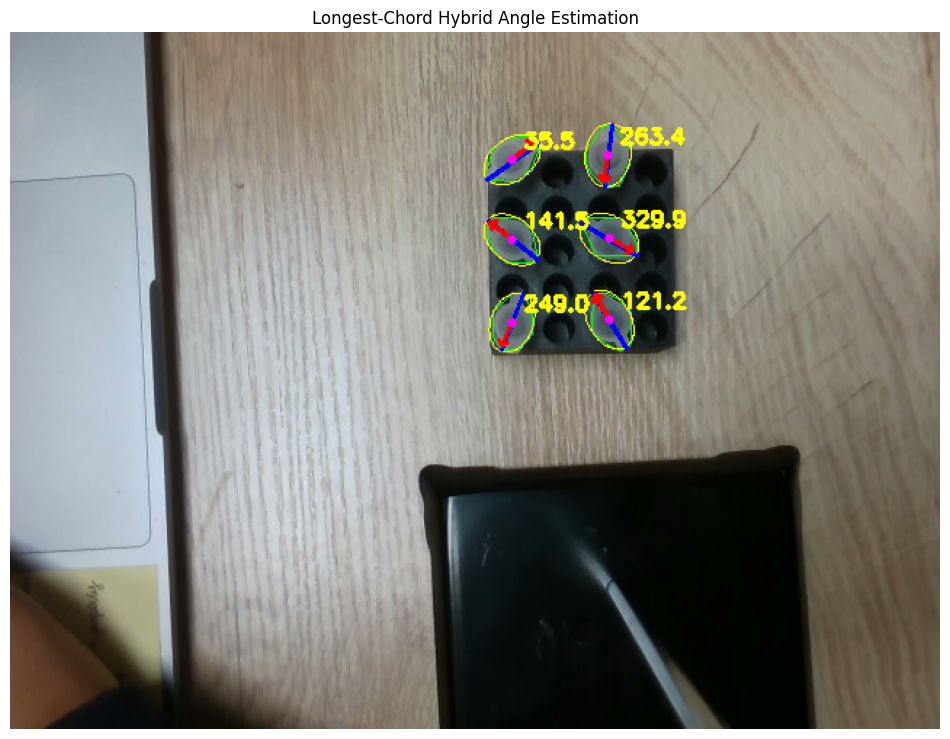


Saved result to:
/content/longest_chord_result.jpg


In [ ]:
#@title Longest Chord method

# ============================================================
# LONGEST-CHORD HYBRID ANGLE ESTIMATION
# ============================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
from inference_sdk import InferenceHTTPClient

# ============================================================
# CONFIG
# ============================================================

API_KEY = "vof93SgrEEFl6QUIp6BI"

# MODEL 1 -> SEGMENTATION
SEGMENTATION_MODEL_ID = "zeon-9tvbv/1"

# MODEL 2 -> KEYPOINTS
KEYPOINT_MODEL_ID = "zeon-2/2"

IMAGE_PATH = "/content/drive/MyDrive/images/2659ffa5-color.png"

PADDING = 15

# ============================================================
# INITIALIZE CLIENT
# ============================================================

CLIENT = InferenceHTTPClient(
    api_url="https://detect.roboflow.com",
    api_key=API_KEY
)

# ============================================================
# LOAD IMAGE
# ============================================================

image = cv2.imread(IMAGE_PATH)

orig = image.copy()

# ============================================================
# RUN SEGMENTATION MODEL
# ============================================================

result = CLIENT.infer(
    IMAGE_PATH,
    model_id=SEGMENTATION_MODEL_ID
)

predictions = result["predictions"]

print(f"\nDetected lids: {len(predictions)}")

# ============================================================
# PROCESS EACH LID
# ============================================================

for idx, pred in enumerate(predictions):

    try:

        # ----------------------------------------------------
        # GET CONTOUR
        # ----------------------------------------------------

        points = pred["points"]

        contour = np.array(
            [[int(p["x"]), int(p["y"])] for p in points],
            dtype=np.int32
        )

        if len(contour) < 5:
            continue

        # ====================================================
        # SMOOTH CONTOUR
        # ====================================================

        contour = cv2.convexHull(contour)

        epsilon = 0.01 * cv2.arcLength(contour, True)

        contour = cv2.approxPolyDP(
            contour,
            epsilon,
            True
        )

        # ====================================================
        # FIT ELLIPSE (ONLY FOR DRAWING)
        # ====================================================

        ellipse = cv2.fitEllipse(contour)

        (cx, cy), (axis1, axis2), raw_angle = ellipse

        cx = int(cx)
        cy = int(cy)

        # ----------------------------------------------------
        # MAJOR / MINOR AXES
        # ----------------------------------------------------

        if axis1 >= axis2:

            major_axis = axis1
            minor_axis = axis2

        else:

            major_axis = axis2
            minor_axis = axis1

        # ====================================================
        # LONGEST CHORD METHOD
        # ====================================================

        pts = contour.reshape(-1, 2)

        max_dist = -1

        best_p1 = None
        best_p2 = None

        # brute-force farthest pair
        for i in range(len(pts)):

            for j in range(i + 1, len(pts)):

                p1 = pts[i]
                p2 = pts[j]

                dist = np.sum((p1 - p2) ** 2)

                if dist > max_dist:

                    max_dist = dist

                    best_p1 = p1
                    best_p2 = p2

        # ----------------------------------------------------
        # CHORD VECTOR
        # ----------------------------------------------------

        chord_vec = best_p2 - best_p1

        chord_norm = np.linalg.norm(chord_vec)

        if chord_norm < 1e-6:
            continue

        chord_vec = chord_vec / chord_norm

        # image coordinate correction
        chord_vec[1] *= -1

        # ----------------------------------------------------
        # CHORD ANGLE
        # ----------------------------------------------------

        major_angle = np.degrees(
            np.arctan2(
                chord_vec[1],
                chord_vec[0]
            )
        )

        major_angle = major_angle % 360

        # ====================================================
        # DRAW CONTOUR
        # ====================================================

        cv2.drawContours(
            orig,
            [contour],
            -1,
            (0,255,0),
            1
        )

        # ====================================================
        # DRAW ELLIPSE
        # ====================================================

        corrected_ellipse = (
            (cx, cy),
            (major_axis, minor_axis),
            (-major_angle) % 360
        )

        cv2.ellipse(
            orig,
            corrected_ellipse,
            (0,255,255),
            1
        )

        # ====================================================
        # DRAW LONGEST CHORD
        # ====================================================

        cv2.line(
            orig,
            tuple(best_p1),
            tuple(best_p2),
            (255,0,0),
            2
        )

        # ====================================================
        # CREATE TIGHT CROP
        # ====================================================

        x, y, w, h = cv2.boundingRect(contour)

        x1 = max(0, x - PADDING)
        y1 = max(0, y - PADDING)

        x2 = min(
            image.shape[1],
            x + w + PADDING
        )

        y2 = min(
            image.shape[0],
            y + h + PADDING
        )

        crop = image[y1:y2, x1:x2]

        crop_path = f"/content/temp_crop_{idx}.jpg"

        cv2.imwrite(crop_path, crop)

        # ====================================================
        # RUN KEYPOINT MODEL
        # ====================================================

        kp_result = CLIENT.infer(
            crop_path,
            model_id=KEYPOINT_MODEL_ID
        )

        kp_predictions = kp_result["predictions"]

        if len(kp_predictions) == 0:
            print(f"No keypoints for lid {idx}")
            continue

        kp = kp_predictions[0]

        keypoints = kp["keypoints"]

        hinge = None
        tab = None

        # ====================================================
        # EXTRACT TAB + HINGE
        # ====================================================

        for k in keypoints:

            cls = k["class"].lower()

            px = k["x"] + x1
            py = k["y"] + y1

            if "hinge" in cls:
                hinge = np.array([px, py])

            elif "tab" in cls:
                tab = np.array([px, py])

        if hinge is None or tab is None:
            print(f"Missing hinge/tab on lid {idx}")
            continue

        # ====================================================
        # TWO POSSIBLE DIRECTIONS
        # ====================================================

        axis_vec_1 = chord_vec
        axis_vec_2 = -chord_vec

        # ====================================================
        # KEYPOINT VECTOR
        # ====================================================

        kp_vec = tab - hinge

        kp_norm = np.linalg.norm(kp_vec)

        if kp_norm < 1e-6:
            continue

        kp_vec = kp_vec / kp_norm

        # image coordinate correction
        kp_vec[1] *= -1

        # ====================================================
        # CHOOSE BEST DIRECTION
        # ====================================================

        dot1 = np.dot(axis_vec_1, kp_vec)
        dot2 = np.dot(axis_vec_2, kp_vec)

        if dot1 >= dot2:
            final_vec = axis_vec_1
        else:
            final_vec = axis_vec_2

        # ====================================================
        # FINAL ANGLE
        # ====================================================

        true_angle = np.degrees(
            np.arctan2(
                final_vec[1],
                final_vec[0]
            )
        )

        true_angle = true_angle % 360

        # ====================================================
        # DRAW FINAL ARROW
        # ====================================================

        arrow_length = int(major_axis * 0.45)

        end_x = int(
            cx + arrow_length * final_vec[0]
        )

        end_y = int(
            cy - arrow_length * final_vec[1]
        )

        cv2.arrowedLine(
            orig,
            (cx, cy),
            (end_x, end_y),
            (0,0,255),
            2,
            tipLength=0.25
        )

        # ====================================================
        # DRAW CENTER
        # ====================================================

        cv2.circle(
            orig,
            (cx, cy),
            3,
            (255,0,255),
            -1
        )

        # ====================================================
        # DRAW TEXT
        # ====================================================

        cv2.putText(
            orig,
            f"{true_angle:.1f}",
            (cx + 8, cy - 8),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (0,255,255),
            2
        )

        print(f"Lid {idx}: {true_angle:.2f} deg")

    except Exception as e:

        print(f"\nFailed on lid {idx}")
        print(e)

# ============================================================
# DISPLAY FINAL RESULT
# ============================================================

rgb = cv2.cvtColor(
    orig,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(12,12))

plt.imshow(rgb)

plt.title("Longest-Chord Hybrid Angle Estimation")

plt.axis("off")

plt.show()

# ============================================================
# SAVE OUTPUT
# ============================================================

output_path = "/content/longest_chord_result.jpg"

cv2.imwrite(output_path, orig)

print(f"\nSaved result to:\n{output_path}")

In [ ]:
#@title Longest Chord CSV generation
# ============================================================
# FULL FOLDER LONGEST-CHORD ANGLE ESTIMATION
# OUTPUT -> predicted_angles_chord.csv
# ============================================================

import os
import cv2
import numpy as np
import pandas as pd
from tqdm import tqdm
from inference_sdk import InferenceHTTPClient

# ============================================================
# CONFIG
# ============================================================

API_KEY = "vof93SgrEEFl6QUIp6BI"

# MODEL 1 -> SEGMENTATION
SEGMENTATION_MODEL_ID = "zeon-9tvbv/1"

# MODEL 2 -> KEYPOINT MODEL
KEYPOINT_MODEL_ID = "zeon-2/2"

IMAGE_FOLDER = "/content/drive/MyDrive/images"

OUTPUT_CSV = "/content/predicted_angles_chord.csv"

PADDING = 15

# ============================================================
# INITIALIZE CLIENT
# ============================================================

CLIENT = InferenceHTTPClient(
    api_url="https://detect.roboflow.com",
    api_key=API_KEY
)

# ============================================================
# STORAGE
# ============================================================

rows = []

# ============================================================
# GET IMAGE FILES
# ============================================================

image_files = sorted([
    f for f in os.listdir(IMAGE_FOLDER)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
])

print(f"\nFound {len(image_files)} images")

# ============================================================
# PROCESS EACH IMAGE
# ============================================================

for image_name in tqdm(image_files):

    image_path = os.path.join(
        IMAGE_FOLDER,
        image_name
    )

    image = cv2.imread(image_path)

    if image is None:
        continue

    try:

        # ====================================================
        # SEGMENTATION INFERENCE
        # ====================================================

        result = CLIENT.infer(
            image_path,
            model_id=SEGMENTATION_MODEL_ID
        )

        predictions = result["predictions"]

        image_rows = []

        # ====================================================
        # PROCESS EACH LID
        # ====================================================

        for idx, pred in enumerate(predictions):

            try:

                # ------------------------------------------------
                # CONTOUR
                # ------------------------------------------------

                points = pred["points"]

                contour = np.array(
                    [[int(p["x"]), int(p["y"])] for p in points],
                    dtype=np.int32
                )

                if len(contour) < 5:
                    continue

                # =================================================
                # SMOOTH CONTOUR
                # =================================================

                contour = cv2.convexHull(contour)

                epsilon = 0.01 * cv2.arcLength(
                    contour,
                    True
                )

                contour = cv2.approxPolyDP(
                    contour,
                    epsilon,
                    True
                )

                pts = contour.reshape(-1, 2)

                if len(pts) < 5:
                    continue

                # =================================================
                # FIT ELLIPSE (CENTER + SIZE ONLY)
                # =================================================

                ellipse = cv2.fitEllipse(contour)

                (cx, cy), (axis1, axis2), _ = ellipse

                # ------------------------------------------------
                # MAJOR AXIS SIZE
                # ------------------------------------------------

                if axis1 >= axis2:
                    major_axis = axis1
                else:
                    major_axis = axis2

                # =================================================
                # LONGEST CHORD
                # =================================================

                max_dist = -1

                best_p1 = None
                best_p2 = None

                for i in range(len(pts)):

                    for j in range(i + 1, len(pts)):

                        p1 = pts[i]
                        p2 = pts[j]

                        dist = np.sum(
                            (p1 - p2) ** 2
                        )

                        if dist > max_dist:

                            max_dist = dist

                            best_p1 = p1
                            best_p2 = p2

                if best_p1 is None:
                    continue

                # =================================================
                # CHORD VECTOR
                # =================================================

                chord_vec = best_p2 - best_p1

                chord_norm = np.linalg.norm(
                    chord_vec
                )

                if chord_norm < 1e-6:
                    continue

                chord_vec = chord_vec / chord_norm

                # image coordinate correction
                chord_vec[1] *= -1

                # =================================================
                # BOUNDING RECT
                # =================================================

                x, y, w, h = cv2.boundingRect(contour)

                x1 = max(0, x - PADDING)
                y1 = max(0, y - PADDING)

                x2 = min(
                    image.shape[1],
                    x + w + PADDING
                )

                y2 = min(
                    image.shape[0],
                    y + h + PADDING
                )

                crop = image[y1:y2, x1:x2]

                crop_path = "/content/temp_crop.jpg"

                cv2.imwrite(crop_path, crop)

                # =================================================
                # KEYPOINT INFERENCE
                # =================================================

                kp_result = CLIENT.infer(
                    crop_path,
                    model_id=KEYPOINT_MODEL_ID
                )

                kp_predictions = kp_result["predictions"]

                if len(kp_predictions) == 0:
                    continue

                kp = kp_predictions[0]

                keypoints = kp["keypoints"]

                hinge = None
                tab = None

                # =================================================
                # EXTRACT KEYPOINTS
                # =================================================

                for k in keypoints:

                    cls = k["class"].lower()

                    px = k["x"] + x1
                    py = k["y"] + y1

                    if "hinge" in cls:
                        hinge = np.array([px, py])

                    elif "tab" in cls:
                        tab = np.array([px, py])

                if hinge is None or tab is None:
                    continue

                # =================================================
                # TWO POSSIBLE DIRECTIONS
                # =================================================

                axis_vec_1 = chord_vec
                axis_vec_2 = -chord_vec

                # =================================================
                # KEYPOINT VECTOR
                # =================================================

                kp_vec = tab - hinge

                kp_norm = np.linalg.norm(kp_vec)

                if kp_norm < 1e-6:
                    continue

                kp_vec = kp_vec / kp_norm

                kp_vec[1] *= -1

                # =================================================
                # CHOOSE DIRECTION
                # =================================================

                dot1 = np.dot(
                    axis_vec_1,
                    kp_vec
                )

                dot2 = np.dot(
                    axis_vec_2,
                    kp_vec
                )

                if dot1 >= dot2:
                    final_vec = axis_vec_1
                else:
                    final_vec = axis_vec_2

                # =================================================
                # FINAL ANGLE
                # =================================================

                true_angle = np.degrees(
                    np.arctan2(
                        final_vec[1],
                        final_vec[0]
                    )
                )

                true_angle = true_angle % 360

                # =================================================
                # SAVE ROW
                # =================================================

                image_rows.append({

                    "image": image_name,

                    "center_x": round(cx, 1),
                    "center_y": round(cy, 1),

                    "bbox_x": round(x, 1),
                    "bbox_y": round(y, 1),

                    "bbox_w": round(w, 1),
                    "bbox_h": round(h, 1),

                    "bbox_rotation": 0,

                    "angle_deg": round(true_angle, 1)
                })

            except Exception:
                continue

        # =====================================================
        # SORT BY POSITION
        # =====================================================

        image_rows = sorted(
            image_rows,
            key=lambda r: (
                r["center_x"],
                r["center_y"]
            )
        )

        rows.extend(image_rows)

    except Exception as e:

        print(f"\nFailed image: {image_name}")
        print(e)

# ============================================================
# SAVE CSV
# ============================================================

df = pd.DataFrame(rows)

df.to_csv(
    OUTPUT_CSV,
    index=False
)

print("\n===================================")
print("DONE")
print("===================================")

print(f"\nSaved CSV:\n{OUTPUT_CSV}")

print(f"\nRows: {len(df)}")


Found 70 images


100%|██████████| 70/70 [04:22<00:00,  3.76s/it]


DONE

Saved CSV:
/content/predicted_angles_chord.csv

Rows: 371



Detected lids: 4
Lid 0: Ellipse=81.3 | PCA=72.1 | Chosen=81.3 | ELLIPSE | diff=9.22
Lid 1: Ellipse=49.3 | PCA=27.8 | Chosen=27.8 | PCA | diff=21.49
Lid 2: Ellipse=352.4 | PCA=347.7 | Chosen=352.4 | ELLIPSE | diff=4.67
Lid 3: Ellipse=133.6 | PCA=125.8 | Chosen=133.6 | ELLIPSE | diff=7.80


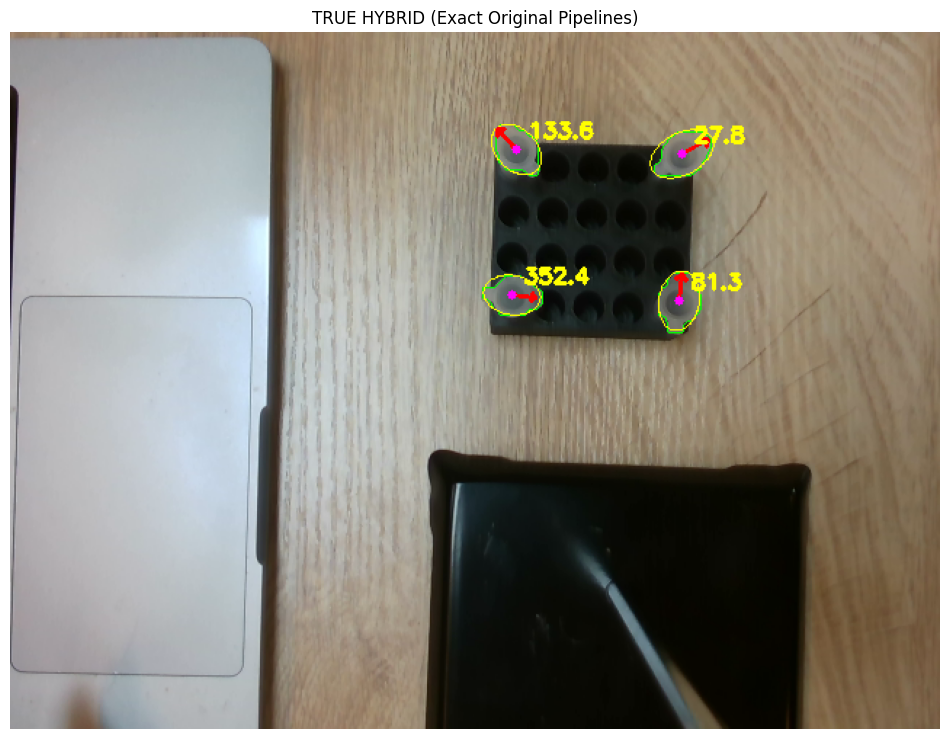

In [ ]:
#@title True Hybrid
# ============================================================
# TRUE HYBRID (FINAL CORRECT VERSION)
#
# CRITICAL DESIGN:
# - Runs ORIGINAL ellipse pipeline independently
# - Runs ORIGINAL PCA pipeline independently
# - Compares FINAL orientation vectors ONLY
# - Chooses one final result
#
# NO shared geometry logic.
# NO reconstructed PCA/ellipse internals.
# ============================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
from inference_sdk import InferenceHTTPClient

# ============================================================
# CONFIG
# ============================================================

API_KEY = "vof93SgrEEFl6QUIp6BI"

SEGMENTATION_MODEL_ID = "zeon-9tvbv/1"
KEYPOINT_MODEL_ID = "zeon-2/2"

IMAGE_PATH = "/content/drive/MyDrive/images/043033e6-color.png"

PADDING = 15

ANGLE_THRESHOLD = 10

# ============================================================
# INITIALIZE CLIENT
# ============================================================

CLIENT = InferenceHTTPClient(
    api_url="https://detect.roboflow.com",
    api_key=API_KEY
)

# ============================================================
# LOAD IMAGE
# ============================================================

image = cv2.imread(IMAGE_PATH)

orig = image.copy()

# ============================================================
# RUN SEGMENTATION MODEL
# ============================================================

result = CLIENT.infer(
    IMAGE_PATH,
    model_id=SEGMENTATION_MODEL_ID
)

predictions = result["predictions"]

print(f"\nDetected lids: {len(predictions)}")

# ============================================================
# PROCESS EACH LID
# ============================================================

for idx, pred in enumerate(predictions):

    try:

        # ====================================================
        # CONTOUR
        # ====================================================

        points = pred["points"]

        contour = np.array(
            [[int(p["x"]), int(p["y"])] for p in points],
            dtype=np.int32
        )

        if len(contour) < 5:
            continue

        # ====================================================
        # PCA SMOOTHING
        # (ONLY PCA VERSION USED THIS)
        # ====================================================

        contour_pca = cv2.convexHull(contour)

        epsilon = 0.01 * cv2.arcLength(
            contour_pca,
            True
        )

        contour_pca = cv2.approxPolyDP(
            contour_pca,
            epsilon,
            True
        )

        # ====================================================
        # ELLIPSE FIT
        # ====================================================

        ellipse = cv2.fitEllipse(contour)

        (cx, cy), (axis1, axis2), raw_angle = ellipse

        cx = int(cx)
        cy = int(cy)

        # ====================================================
        # ELLIPSE PIPELINE
        # EXACT ORIGINAL LOGIC
        # ====================================================

        if axis1 >= axis2:

            ellipse_major_axis = axis1
            ellipse_minor_axis = axis2
            ellipse_major_angle = raw_angle

        else:

            ellipse_major_axis = axis2
            ellipse_minor_axis = axis1
            ellipse_major_angle = raw_angle + 90

        ellipse_major_angle = (
            ellipse_major_angle % 360
        )

        # ORIGINAL ellipse vector
        theta_e = np.deg2rad(
            ellipse_major_angle
        )

        ellipse_axis_vec = np.array([
            np.cos(theta_e),
            -np.sin(theta_e)
        ])

        # ====================================================
        # PCA PIPELINE
        # EXACT ORIGINAL LOGIC
        # ====================================================

        pts = contour_pca.reshape(
            -1,
            2
        ).astype(np.float32)

        mean, eigenvectors = cv2.PCACompute(
            pts,
            mean=None
        )

        principal_vec = eigenvectors[0]

        vx = principal_vec[0]
        vy = principal_vec[1]

        # EXACT original correction
        vy = -vy

        pca_major_angle = np.degrees(
            np.arctan2(vy, vx)
        )

        pca_major_angle = (
            pca_major_angle % 360
        )

        # ORIGINAL PCA vector
        theta_p = np.deg2rad(
            pca_major_angle
        )

        pca_axis_vec = np.array([
            np.cos(theta_p),
            np.sin(theta_p)
        ])

        # ====================================================
        # CREATE CROP
        # ====================================================

        x, y, w, h = cv2.boundingRect(
            contour
        )

        x1 = max(0, x - PADDING)
        y1 = max(0, y - PADDING)

        x2 = min(
            image.shape[1],
            x + w + PADDING
        )

        y2 = min(
            image.shape[0],
            y + h + PADDING
        )

        crop = image[
            y1:y2,
            x1:x2
        ]

        crop_path = (
            f"/content/temp_crop_{idx}.jpg"
        )

        cv2.imwrite(
            crop_path,
            crop
        )

        # ====================================================
        # KEYPOINT MODEL
        # ====================================================

        kp_result = CLIENT.infer(
            crop_path,
            model_id=KEYPOINT_MODEL_ID
        )

        kp_predictions = (
            kp_result["predictions"]
        )

        if len(kp_predictions) == 0:
            continue

        kp = kp_predictions[0]

        keypoints = kp["keypoints"]

        hinge = None
        tab = None

        # ====================================================
        # EXTRACT KEYPOINTS
        # ====================================================

        for k in keypoints:

            cls = k["class"].lower()

            px = k["x"] + x1
            py = k["y"] + y1

            if "hinge" in cls:

                hinge = np.array([px, py])

            elif "tab" in cls:

                tab = np.array([px, py])

        if hinge is None or tab is None:
            continue

        # ====================================================
        # KEYPOINT VECTOR
        # ====================================================

        kp_vec = tab - hinge

        kp_norm = np.linalg.norm(
            kp_vec
        )

        if kp_norm < 1e-6:
            continue

        kp_vec = kp_vec / kp_norm

        # EXACT original correction
        kp_vec[1] *= -1

        # ====================================================
        # ORIGINAL ELLIPSE DIRECTION RESOLUTION
        # ====================================================

        ellipse_axis_vec_1 = ellipse_axis_vec
        ellipse_axis_vec_2 = -ellipse_axis_vec

        dot1 = np.dot(
            ellipse_axis_vec_1,
            kp_vec
        )

        dot2 = np.dot(
            ellipse_axis_vec_2,
            kp_vec
        )

        if dot1 >= dot2:

            ellipse_final_vec = (
                ellipse_axis_vec_1
            )

        else:

            ellipse_final_vec = (
                ellipse_axis_vec_2
            )

        # FINAL ellipse angle
        ellipse_true_angle = np.degrees(
            np.arctan2(
                -ellipse_final_vec[1],
                ellipse_final_vec[0]
            )
        )

        ellipse_true_angle = (
            ellipse_true_angle % 360
        )

        ellipse_true_angle = (
            360 - ellipse_true_angle
        ) % 360

        # ====================================================
        # ORIGINAL PCA DIRECTION RESOLUTION
        # ====================================================

        pca_axis_vec_1 = pca_axis_vec
        pca_axis_vec_2 = -pca_axis_vec

        dot1 = np.dot(
            pca_axis_vec_1,
            kp_vec
        )

        dot2 = np.dot(
            pca_axis_vec_2,
            kp_vec
        )

        if dot1 >= dot2:

            pca_final_vec = (
                pca_axis_vec_1
            )

        else:

            pca_final_vec = (
                pca_axis_vec_2
            )

        # FINAL PCA angle
        pca_true_angle = np.degrees(
            np.arctan2(
                pca_final_vec[1],
                pca_final_vec[0]
            )
        )

        pca_true_angle = (
            pca_true_angle % 360
        )

        # ====================================================
        # TRUE GEOMETRIC DISAGREEMENT
        # Compare FINAL outputs ONLY
        # ====================================================

        dot = np.dot(
            ellipse_final_vec,
            pca_final_vec
        )

        dot = np.clip(dot, -1, 1)

        dot = abs(dot)

        disagreement = np.degrees(
            np.arccos(dot)
        )

        # ====================================================
        # SELECT METHOD
        # ====================================================

        if disagreement > ANGLE_THRESHOLD:

            selected_method = "PCA"

            final_vec = pca_final_vec

            true_angle = pca_true_angle

            ellipse_draw_angle = (
                -pca_major_angle
            ) % 360

        else:

            selected_method = "ELLIPSE"

            final_vec = ellipse_final_vec

            true_angle = ellipse_true_angle

            ellipse_draw_angle = (
                ellipse_major_angle
            )

        # ====================================================
        # DRAW CONTOUR
        # ====================================================

        cv2.drawContours(
            orig,
            [contour],
            -1,
            (0,255,0),
            1
        )

        # ====================================================
        # DRAW ELLIPSE
        # ====================================================

        corrected_ellipse = (
            (cx, cy),
            (
                ellipse_major_axis,
                ellipse_minor_axis
            ),
            ellipse_draw_angle
        )

        cv2.ellipse(
            orig,
            corrected_ellipse,
            (0,255,255),
            1
        )

        # ====================================================
        # DRAW ARROW
        # ====================================================

        arrow_length = int(
            ellipse_major_axis * 0.45
        )

        end_x = int(
            cx +
            arrow_length *
            final_vec[0]
        )

        end_y = int(
            cy -
            arrow_length *
            final_vec[1]
        )

        cv2.arrowedLine(
            orig,
            (cx, cy),
            (end_x, end_y),
            (0,0,255),
            2,
            tipLength=0.25
        )

        # ====================================================
        # DRAW CENTER
        # ====================================================

        cv2.circle(
            orig,
            (cx, cy),
            3,
            (255,0,255),
            -1
        )

        # ====================================================
        # DRAW TEXT
        # ====================================================

        cv2.putText(
            orig,
            f"{true_angle:.1f}",
            (cx + 8, cy - 8),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (0,255,255),
            2
        )

        print(
            f"Lid {idx}: "
            f"Ellipse={ellipse_true_angle:.1f} | "
            f"PCA={pca_true_angle:.1f} | "
            f"Chosen={true_angle:.1f} | "
            f"{selected_method} | "
            f"diff={disagreement:.2f}"
        )

    except Exception as e:

        print(f"\nFailed on lid {idx}")
        print(e)

# ============================================================
# DISPLAY
# ============================================================

rgb = cv2.cvtColor(
    orig,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(12,12))

plt.imshow(rgb)

plt.title(
    "TRUE HYBRID (Exact Original Pipelines)"
)

plt.axis("off")

plt.show()

In [ ]:
#@title CSV generation quick
# ============================================================
# TRUE HYBRID -> CSV GENERATION
#
# EXACT SAME LOGIC AS VALIDATED VISUALIZATION NOTEBOOK
#
# ONLY CHANGES:
# - loops through folder
# - removes drawing/plotting
# - saves CSV
#
# NOTHING ELSE CHANGED.
# ============================================================

import os
import cv2
import numpy as np
import pandas as pd
from tqdm import tqdm
from inference_sdk import InferenceHTTPClient

# ============================================================
# CONFIG
# ============================================================

API_KEY = "vof93SgrEEFl6QUIp6BI"

SEGMENTATION_MODEL_ID = "zeon-9tvbv/1"
KEYPOINT_MODEL_ID = "zeon-2/2"

IMAGE_FOLDER = "/content/drive/MyDrive/images"

OUTPUT_CSV = (
    "/content/final_true_hybrid_predictions.csv"
)

PADDING = 15

ANGLE_THRESHOLD = 10

# ============================================================
# INITIALIZE CLIENT
# ============================================================

CLIENT = InferenceHTTPClient(
    api_url="https://detect.roboflow.com",
    api_key=API_KEY
)

# ============================================================
# STORAGE
# ============================================================

rows = []

# ============================================================
# IMAGE FILES
# ============================================================

image_files = sorted([
    f for f in os.listdir(IMAGE_FOLDER)
    if f.lower().endswith((
        ".jpg",
        ".jpeg",
        ".png"
    ))
])

print(f"\nFound {len(image_files)} images")

# ============================================================
# PROCESS EACH IMAGE
# ============================================================

for image_name in tqdm(image_files):

    IMAGE_PATH = os.path.join(
        IMAGE_FOLDER,
        image_name
    )

    image = cv2.imread(IMAGE_PATH)

    if image is None:
        continue

    try:

        # ====================================================
        # RUN SEGMENTATION MODEL
        # ====================================================

        result = CLIENT.infer(
            IMAGE_PATH,
            model_id=SEGMENTATION_MODEL_ID
        )

        predictions = result["predictions"]

        # ====================================================
        # PROCESS EACH LID
        # ====================================================

        for idx, pred in enumerate(predictions):

            try:

                # ====================================================
                # CONTOUR
                # ====================================================

                points = pred["points"]

                contour = np.array(
                    [[int(p["x"]), int(p["y"])] for p in points],
                    dtype=np.int32
                )

                if len(contour) < 5:
                    continue

                # ====================================================
                # PCA SMOOTHING
                # ====================================================

                contour_pca = cv2.convexHull(contour)

                epsilon = 0.01 * cv2.arcLength(
                    contour_pca,
                    True
                )

                contour_pca = cv2.approxPolyDP(
                    contour_pca,
                    epsilon,
                    True
                )

                # ====================================================
                # ELLIPSE FIT
                # ====================================================

                ellipse = cv2.fitEllipse(contour)

                (cx, cy), (axis1, axis2), raw_angle = ellipse

                # cx = int(cx)
                # cy = int(cy)

                # ====================================================
                # ELLIPSE PIPELINE
                # ====================================================

                if axis1 >= axis2:

                    ellipse_major_axis = axis1
                    ellipse_minor_axis = axis2
                    ellipse_major_angle = raw_angle

                else:

                    ellipse_major_axis = axis2
                    ellipse_minor_axis = axis1
                    ellipse_major_angle = raw_angle + 90

                ellipse_major_angle = (
                    ellipse_major_angle % 360
                )

                theta_e = np.deg2rad(
                    ellipse_major_angle
                )

                ellipse_axis_vec = np.array([
                    np.cos(theta_e),
                    -np.sin(theta_e)
                ])

                # ====================================================
                # PCA PIPELINE
                # ====================================================

                pts = contour_pca.reshape(
                    -1,
                    2
                ).astype(np.float32)

                mean, eigenvectors = cv2.PCACompute(
                    pts,
                    mean=None
                )

                principal_vec = eigenvectors[0]

                vx = principal_vec[0]
                vy = principal_vec[1]

                vy = -vy

                pca_major_angle = np.degrees(
                    np.arctan2(vy, vx)
                )

                pca_major_angle = (
                    pca_major_angle % 360
                )

                theta_p = np.deg2rad(
                    pca_major_angle
                )

                pca_axis_vec = np.array([
                    np.cos(theta_p),
                    np.sin(theta_p)
                ])

                # ====================================================
                # CREATE CROP
                # ====================================================

                x, y, w, h = cv2.boundingRect(
                    contour
                )

                x1 = max(0, x - PADDING)
                y1 = max(0, y - PADDING)

                x2 = min(
                    image.shape[1],
                    x + w + PADDING
                )

                y2 = min(
                    image.shape[0],
                    y + h + PADDING
                )

                crop = image[
                    y1:y2,
                    x1:x2
                ]

                # EXACT SAME crop logic
                crop_path = (
                    f"/content/temp_crop_{idx}.jpg"
                )

                cv2.imwrite(
                    crop_path,
                    crop
                )

                # ====================================================
                # KEYPOINT MODEL
                # ====================================================

                kp_result = CLIENT.infer(
                    crop_path,
                    model_id=KEYPOINT_MODEL_ID
                )

                kp_predictions = (
                    kp_result["predictions"]
                )

                if len(kp_predictions) == 0:
                    continue

                kp = kp_predictions[0]

                keypoints = kp["keypoints"]

                hinge = None
                tab = None

                # ====================================================
                # EXTRACT KEYPOINTS
                # ====================================================

                for k in keypoints:

                    cls = k["class"].lower()

                    px = k["x"] + x1
                    py = k["y"] + y1

                    if "hinge" in cls:

                        hinge = np.array([px, py])

                    elif "tab" in cls:

                        tab = np.array([px, py])

                if hinge is None or tab is None:
                    continue

                # ====================================================
                # KEYPOINT VECTOR
                # ====================================================

                kp_vec = tab - hinge

                kp_norm = np.linalg.norm(
                    kp_vec
                )

                if kp_norm < 1e-6:
                    continue

                kp_vec = kp_vec / kp_norm

                kp_vec[1] *= -1

                # ====================================================
                # ELLIPSE DIRECTION RESOLUTION
                # ====================================================

                ellipse_axis_vec_1 = ellipse_axis_vec
                ellipse_axis_vec_2 = -ellipse_axis_vec

                dot1 = np.dot(
                    ellipse_axis_vec_1,
                    kp_vec
                )

                dot2 = np.dot(
                    ellipse_axis_vec_2,
                    kp_vec
                )

                if dot1 >= dot2:

                    ellipse_final_vec = (
                        ellipse_axis_vec_1
                    )

                else:

                    ellipse_final_vec = (
                        ellipse_axis_vec_2
                    )

                ellipse_true_angle = np.degrees(
                    np.arctan2(
                        -ellipse_final_vec[1],
                        ellipse_final_vec[0]
                    )
                )

                ellipse_true_angle = (
                    ellipse_true_angle % 360
                )

                ellipse_true_angle = (
                    360 - ellipse_true_angle
                ) % 360

                # ====================================================
                # PCA DIRECTION RESOLUTION
                # ====================================================

                pca_axis_vec_1 = pca_axis_vec
                pca_axis_vec_2 = -pca_axis_vec

                dot1 = np.dot(
                    pca_axis_vec_1,
                    kp_vec
                )

                dot2 = np.dot(
                    pca_axis_vec_2,
                    kp_vec
                )

                if dot1 >= dot2:

                    pca_final_vec = (
                        pca_axis_vec_1
                    )

                else:

                    pca_final_vec = (
                        pca_axis_vec_2
                    )

                pca_true_angle = np.degrees(
                    np.arctan2(
                        pca_final_vec[1],
                        pca_final_vec[0]
                    )
                )

                pca_true_angle = (
                    pca_true_angle % 360
                )

                # ====================================================
                # TRUE GEOMETRIC DISAGREEMENT
                # ====================================================

                dot = np.dot(
                    ellipse_final_vec,
                    pca_final_vec
                )

                dot = np.clip(dot, -1, 1)

                dot = abs(dot)

                disagreement = np.degrees(
                    np.arccos(dot)
                )

                # ====================================================
                # SELECT METHOD
                # ====================================================

                if disagreement > ANGLE_THRESHOLD:

                    selected_method = "PCA"

                    final_vec = pca_final_vec

                    true_angle = pca_true_angle

                else:

                    selected_method = "ELLIPSE"

                    final_vec = ellipse_final_vec

                    true_angle = ellipse_true_angle

                # ====================================================
                # SAVE FINAL OUTPUT
                # ====================================================

                rows.append({

                    "image": image_name,

                    "center_x": cx,
                    "center_y": cy,

                    "hybrid_angle":
                        round(true_angle, 3)
                })

            except Exception:
                continue

    except Exception as e:

        print(f"\nFailed image: {image_name}")
        print(e)

# ============================================================
# SAVE CSV
# ============================================================

df = pd.DataFrame(rows)

df.to_csv(
    OUTPUT_CSV,
    index=False
)

print("\n===================================")
print("DONE")
print("===================================")

print(f"\nSaved CSV:\n{OUTPUT_CSV}")

print(f"\nRows: {len(df)}")


Found 70 images


100%|██████████| 70/70 [01:59<00:00,  1.71s/it]


DONE

Saved CSV:
/content/final_true_hybrid_predictions.csv

Rows: 371


In [ ]:
#@title Join CSVs
import pandas as pd
import numpy as np
from scipy.spatial.distance import cdist

# =========================================================
# LOAD CSVS
# =========================================================

gt_df = pd.read_csv("/content/annotations.csv")
pred_df = pd.read_csv("/content/final_true_hybrid_predictions.csv")

# =========================================================
# FINAL MATCH STORAGE
# =========================================================

matched_rows = []

# =========================================================
# PROCESS IMAGE BY IMAGE
# =========================================================

common_images = sorted(
    set(gt_df["image"]).intersection(
        set(pred_df["image"])
    )
)

print(f"Common images: {len(common_images)}")

for image_name in common_images:

    gt_img = gt_df[
        gt_df["image"] == image_name
    ].reset_index(drop=True)

    pred_img = pred_df[
        pred_df["image"] == image_name
    ].reset_index(drop=True)

    if len(gt_img) == 0 or len(pred_img) == 0:
        continue

    # -----------------------------------------------------
    # GET POINTS
    # -----------------------------------------------------

    gt_pts = gt_img[["center_x", "center_y"]].values
    pred_pts = pred_img[["center_x", "center_y"]].values

    # -----------------------------------------------------
    # DISTANCE MATRIX
    # -----------------------------------------------------

    dist_matrix = cdist(gt_pts, pred_pts)

    # -----------------------------------------------------
    # GREEDY ONE-TO-ONE MATCHING
    # -----------------------------------------------------

    used_gt = set()
    used_pred = set()

    while (
        len(used_gt) < len(gt_pts)
        and
        len(used_pred) < len(pred_pts)
    ):

        min_dist = np.inf
        best_gt = None
        best_pred = None

        # search smallest unmatched pair
        for i in range(len(gt_pts)):

            if i in used_gt:
                continue

            for j in range(len(pred_pts)):

                if j in used_pred:
                    continue

                d = dist_matrix[i, j]

                if d < min_dist:

                    min_dist = d
                    best_gt = i
                    best_pred = j

        if best_gt is None:
            break

        used_gt.add(best_gt)
        used_pred.add(best_pred)

        gt_row = gt_img.iloc[best_gt]
        pred_row = pred_img.iloc[best_pred]

        # -------------------------------------------------
        # ANGLE ERROR
        # -------------------------------------------------

        gt_angle = gt_row["angle_deg"]
        pred_angle = pred_row["hybrid_angle"]

        diff = abs(gt_angle - pred_angle)
        diff = min(diff, 360 - diff)

        # optional flip correction
        flip_diff = abs(
            gt_angle - ((pred_angle + 180) % 360)
        )

        flip_diff = min(flip_diff, 360 - flip_diff)

        best_error = min(diff, flip_diff)

        matched_rows.append({

            "image": image_name,

            "gt_center_x": gt_row["center_x"],
            "gt_center_y": gt_row["center_y"],

            "pred_center_x": pred_row["center_x"],
            "pred_center_y": pred_row["center_y"],

            "center_distance": min_dist,

            "gt_angle": gt_angle,
            "pred_angle": pred_angle,

            "angle_error": best_error
        })

# =========================================================
# FINAL RESULTS
# =========================================================

match_df = pd.DataFrame(matched_rows)

print("\n===================================")
print("SPATIAL MATCHING RESULTS")
print("===================================")

print(f"\nMatched lids: {len(match_df)}")

print("\nCenter Distance:")
print(f"Mean   : {match_df['center_distance'].mean():.2f}")
print(f"Median : {match_df['center_distance'].median():.2f}")

print("\nAngle Error:")
print(f"Mean   : {match_df['angle_error'].mean():.2f}")
print(f"Median : {match_df['angle_error'].median():.2f}")
print(f"Max    : {match_df['angle_error'].max():.2f}")

# =========================================================
# SAVE
# =========================================================

output_csv = "/content/Model_Comparison.csv"

match_df.to_csv(output_csv, index=False)

print(f"\nSaved:\n{output_csv}")

Common images: 70

SPATIAL MATCHING RESULTS

Matched lids: 371

Center Distance:
Mean   : 1.50
Median : 1.39

Angle Error:
Mean   : 4.99
Median : 4.01
Max    : 23.25

Saved:
/content/Model_Comparison.csv


In [ ]:
#@title Get overlay images' folder and CSV
# ============================================================
# TRUE HYBRID -> OVERLAY FOLDER + CSV
#
# EXACT SAME VALIDATED PIPELINE
#
# ONLY ADDED:
# - overlay saving
# - folder loop
# - csv export
#
# NO LOGIC CHANGED.
# ============================================================

import os
import cv2
import numpy as np
import pandas as pd
from tqdm import tqdm
from inference_sdk import InferenceHTTPClient

# ============================================================
# CONFIG
# ============================================================

API_KEY = "vof93SgrEEFl6QUIp6BI"

SEGMENTATION_MODEL_ID = "zeon-9tvbv/1"
KEYPOINT_MODEL_ID = "zeon-2/2"

IMAGE_FOLDER = "/content/drive/MyDrive/images"

OUTPUT_FOLDER = (
    "/content/final_overlay_images"
)

OUTPUT_CSV = (
    "/content/final_true_hybrid_predictions.csv"
)

PADDING = 15

ANGLE_THRESHOLD = 10

# ============================================================
# CREATE OUTPUT FOLDER
# ============================================================

os.makedirs(
    OUTPUT_FOLDER,
    exist_ok=True
)

# ============================================================
# INITIALIZE CLIENT
# ============================================================

CLIENT = InferenceHTTPClient(
    api_url="https://detect.roboflow.com",
    api_key=API_KEY
)

# ============================================================
# STORAGE
# ============================================================

rows = []

# ============================================================
# IMAGE FILES
# ============================================================

image_files = sorted([
    f for f in os.listdir(IMAGE_FOLDER)
    if f.lower().endswith((
        ".jpg",
        ".jpeg",
        ".png"
    ))
])

print(f"\nFound {len(image_files)} images")

# ============================================================
# PROCESS EACH IMAGE
# ============================================================

for image_name in tqdm(image_files):

    IMAGE_PATH = os.path.join(
        IMAGE_FOLDER,
        image_name
    )

    image = cv2.imread(IMAGE_PATH)

    if image is None:
        continue

    orig = image.copy()

    try:

        # ====================================================
        # RUN SEGMENTATION MODEL
        # ====================================================

        result = CLIENT.infer(
            IMAGE_PATH,
            model_id=SEGMENTATION_MODEL_ID
        )

        predictions = result["predictions"]

        # ====================================================
        # PROCESS EACH LID
        # ====================================================

        for idx, pred in enumerate(predictions):

            try:

                # ====================================================
                # CONTOUR
                # ====================================================

                points = pred["points"]

                contour = np.array(
                    [[int(p["x"]), int(p["y"])] for p in points],
                    dtype=np.int32
                )

                if len(contour) < 5:
                    continue

                # ====================================================
                # PCA SMOOTHING
                # ====================================================

                contour_pca = cv2.convexHull(contour)

                epsilon = 0.01 * cv2.arcLength(
                    contour_pca,
                    True
                )

                contour_pca = cv2.approxPolyDP(
                    contour_pca,
                    epsilon,
                    True
                )

                # ====================================================
                # ELLIPSE FIT
                # ====================================================

                ellipse = cv2.fitEllipse(contour)

                (cx, cy), (axis1, axis2), raw_angle = ellipse

                # EXACT SAME LOGIC
                # DO NOT CHANGE
                # cx = int(cx)
                # cy = int(cy)

                # ====================================================
                # ELLIPSE PIPELINE
                # ====================================================

                if axis1 >= axis2:

                    ellipse_major_axis = axis1
                    ellipse_minor_axis = axis2
                    ellipse_major_angle = raw_angle

                else:

                    ellipse_major_axis = axis2
                    ellipse_minor_axis = axis1
                    ellipse_major_angle = raw_angle + 90

                ellipse_major_angle = (
                    ellipse_major_angle % 360
                )

                theta_e = np.deg2rad(
                    ellipse_major_angle
                )

                ellipse_axis_vec = np.array([
                    np.cos(theta_e),
                    -np.sin(theta_e)
                ])

                # ====================================================
                # PCA PIPELINE
                # ====================================================

                pts = contour_pca.reshape(
                    -1,
                    2
                ).astype(np.float32)

                mean, eigenvectors = cv2.PCACompute(
                    pts,
                    mean=None
                )

                principal_vec = eigenvectors[0]

                vx = principal_vec[0]
                vy = principal_vec[1]

                vy = -vy

                pca_major_angle = np.degrees(
                    np.arctan2(vy, vx)
                )

                pca_major_angle = (
                    pca_major_angle % 360
                )

                theta_p = np.deg2rad(
                    pca_major_angle
                )

                pca_axis_vec = np.array([
                    np.cos(theta_p),
                    np.sin(theta_p)
                ])

                # ====================================================
                # CREATE CROP
                # ====================================================

                x, y, w, h = cv2.boundingRect(
                    contour
                )

                x1 = max(0, x - PADDING)
                y1 = max(0, y - PADDING)

                x2 = min(
                    image.shape[1],
                    x + w + PADDING
                )

                y2 = min(
                    image.shape[0],
                    y + h + PADDING
                )

                crop = image[
                    y1:y2,
                    x1:x2
                ]

                crop_path = (
                    f"/content/temp_crop_{idx}.jpg"
                )

                cv2.imwrite(
                    crop_path,
                    crop
                )

                # ====================================================
                # KEYPOINT MODEL
                # ====================================================

                kp_result = CLIENT.infer(
                    crop_path,
                    model_id=KEYPOINT_MODEL_ID
                )

                kp_predictions = (
                    kp_result["predictions"]
                )

                if len(kp_predictions) == 0:
                    continue

                kp = kp_predictions[0]

                keypoints = kp["keypoints"]

                hinge = None
                tab = None

                # ====================================================
                # EXTRACT KEYPOINTS
                # ====================================================

                for k in keypoints:

                    cls = k["class"].lower()

                    px = k["x"] + x1
                    py = k["y"] + y1

                    if "hinge" in cls:

                        hinge = np.array([px, py])

                    elif "tab" in cls:

                        tab = np.array([px, py])

                if hinge is None or tab is None:
                    continue

                # ====================================================
                # KEYPOINT VECTOR
                # ====================================================

                kp_vec = tab - hinge

                kp_norm = np.linalg.norm(
                    kp_vec
                )

                if kp_norm < 1e-6:
                    continue

                kp_vec = kp_vec / kp_norm

                kp_vec[1] *= -1

                # ====================================================
                # ELLIPSE DIRECTION RESOLUTION
                # ====================================================

                ellipse_axis_vec_1 = ellipse_axis_vec
                ellipse_axis_vec_2 = -ellipse_axis_vec

                dot1 = np.dot(
                    ellipse_axis_vec_1,
                    kp_vec
                )

                dot2 = np.dot(
                    ellipse_axis_vec_2,
                    kp_vec
                )

                if dot1 >= dot2:

                    ellipse_final_vec = (
                        ellipse_axis_vec_1
                    )

                else:

                    ellipse_final_vec = (
                        ellipse_axis_vec_2
                    )

                ellipse_true_angle = np.degrees(
                    np.arctan2(
                        -ellipse_final_vec[1],
                        ellipse_final_vec[0]
                    )
                )

                ellipse_true_angle = (
                    ellipse_true_angle % 360
                )

                ellipse_true_angle = (
                    360 - ellipse_true_angle
                ) % 360

                # ====================================================
                # PCA DIRECTION RESOLUTION
                # ====================================================

                pca_axis_vec_1 = pca_axis_vec
                pca_axis_vec_2 = -pca_axis_vec

                dot1 = np.dot(
                    pca_axis_vec_1,
                    kp_vec
                )

                dot2 = np.dot(
                    pca_axis_vec_2,
                    kp_vec
                )

                if dot1 >= dot2:

                    pca_final_vec = (
                        pca_axis_vec_1
                    )

                else:

                    pca_final_vec = (
                        pca_axis_vec_2
                    )

                pca_true_angle = np.degrees(
                    np.arctan2(
                        pca_final_vec[1],
                        pca_final_vec[0]
                    )
                )

                pca_true_angle = (
                    pca_true_angle % 360
                )

                # ====================================================
                # TRUE GEOMETRIC DISAGREEMENT
                # ====================================================

                dot = np.dot(
                    ellipse_final_vec,
                    pca_final_vec
                )

                dot = np.clip(dot, -1, 1)

                dot = abs(dot)

                disagreement = np.degrees(
                    np.arccos(dot)
                )

                # ====================================================
                # SELECT METHOD
                # ====================================================

                if disagreement > ANGLE_THRESHOLD:

                    selected_method = "PCA"

                    final_vec = pca_final_vec

                    true_angle = pca_true_angle

                    ellipse_draw_angle = (
                        -pca_major_angle
                    ) % 360

                else:

                    selected_method = "ELLIPSE"

                    final_vec = ellipse_final_vec

                    true_angle = ellipse_true_angle

                    ellipse_draw_angle = (
                        ellipse_major_angle
                    )

                # ====================================================
                # DRAW OVERLAY
                # ====================================================

                cv2.drawContours(
                    orig,
                    [contour],
                    -1,
                    (0,255,0),
                    1
                )

                corrected_ellipse = (
                    (int(cx), int(cy)),
                    (
                        ellipse_major_axis,
                        ellipse_minor_axis
                    ),
                    ellipse_draw_angle
                )

                cv2.ellipse(
                    orig,
                    corrected_ellipse,
                    (0,255,255),
                    1
                )

                arrow_length = int(
                    ellipse_major_axis * 0.45
                )

                end_x = int(
                    cx +
                    arrow_length *
                    final_vec[0]
                )

                end_y = int(
                    cy -
                    arrow_length *
                    final_vec[1]
                )

                cv2.arrowedLine(
                    orig,
                    (int(cx), int(cy)),
                    (end_x, end_y),
                    (0,0,255),
                    2,
                    tipLength=0.25
                )

                cv2.circle(
                    orig,
                    (int(cx), int(cy)),
                    3,
                    (255,0,255),
                    -1
                )

                cv2.putText(
                    orig,
                    f"{true_angle:.1f}",
                    (int(cx)+8, int(cy)-8),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.5,
                    (0,255,255),
                    2
                )

                # ====================================================
                # SAVE CSV ROW
                # ====================================================

                rows.append({

                    "image": image_name,

                    "center_x": cx,
                    "center_y": cy,

                    "hybrid_angle":
                        round(true_angle, 3)
                })

            except Exception:
                continue

        # ====================================================
        # SAVE OVERLAY IMAGE
        # ====================================================

        save_path = os.path.join(
            OUTPUT_FOLDER,
            image_name
        )

        cv2.imwrite(
            save_path,
            orig,
            [
                cv2.IMWRITE_PNG_COMPRESSION,
                9
            ]
        )

    except Exception as e:

        print(f"\nFailed image: {image_name}")
        print(e)

# ============================================================
# SAVE CSV
# ============================================================

df = pd.DataFrame(rows)

df.to_csv(
    OUTPUT_CSV,
    index=False
)

print("\n===================================")
print("DONE")
print("===================================")

print(f"\nOverlay folder:\n{OUTPUT_FOLDER}")

print(f"\nCSV:\n{OUTPUT_CSV}")

print(f"\nRows: {len(df)}")


Found 70 images


100%|██████████| 70/70 [02:46<00:00,  2.38s/it]


DONE

Overlay folder:
/content/final_overlay_images

CSV:
/content/final_true_hybrid_predictions.csv

Rows: 371


In [ ]:
#@title Download folder of overlay images
from google.colab import files
import shutil

shutil.make_archive(
    "/content/final_overlay_images",
    'zip',
    "/content/final_overlay_images"
)

files.download(
    "/content/final_overlay_images.zip"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>